# ml problem life-cycle 
- problem understanding
- data collection
- data understanting
- data processing
- model evaluation
- model seletion
- model deployment
- model monitoring

## problem : 
- ice-cream sale prediction based on temperature
- dataset: icecream_sales_dataset.csv
- model:simple Linear Regression

In [1]:
# installion
# %pip install scikit-learn

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [3]:
# load data
data=pd.read_csv(r"icecream_sales_dataset (2).csv")
data.head()

,Temperature_C,IceCream_Sales
0,30.523830,875.871197
1,26.956777,810.412847
2,36.489760,1109.021413
3,23.796323,710.135154
4,15.308535,472.521514


In [4]:
# data back-up
df=data.copy()

In [5]:
# meta=data
print("no. of rows:",df.shape[0])
print("no. of columns :",df.shape[1])
print("all columns :",df.columns)
print("overall info: \n")
df.info()

no. of rows: 10020
no. of columns : 2
all columns : Index(['Temperature_C', 'IceCream_Sales'], dtype='str')
overall info: 

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature_C   10010 non-null  float64
 1   IceCream_Sales  10010 non-null  float64
dtypes: float64(2)
memory usage: 156.7 KB


data_preprocessing
- data type
- duplicate
- null value
- data reduction
- outliners
- feature engineering
- scling & normalization
- encoding
- train_test_split

In [6]:
# dulicate 
print("total duplicat count",df.duplicated().sum())
print("duplicate row: \n")
df[df.duplicated()]

total duplicat count 20
duplicate row: 



,Temperature_C,IceCream_Sales
1457,17.440463,519.788776
3917,30.817654,924.451385
3922,29.778543,931.610047
4273,26.644971,794.960889
4324,22.423889,663.418223
5377,25.574431,782.456790
5404,25.124311,777.073261
6010,22.010713,654.411788
6296,23.935782,706.354443
6392,43.842527,1331.176249


In [7]:
# remove duplicate 
df.drop_duplicates(inplace=True)
print("total duplicat count",df.duplicated().sum())

total duplicat count 0


In [8]:
# null value
df.isnull().sum()

Temperature_C     10
IceCream_Sales    10
dtype: int64

In [9]:
# drop null
df.dropna(inplace=True)
df.isnull().sum()

Temperature_C     0
IceCream_Sales    0
dtype: int64

In [10]:
# descriptive statistics
df.describe()

,Temperature_C,IceCream_Sales
count,9980.000000,9980.000000
mean,29.822430,894.914653
std,8.631672,259.482712
min,15.000349,386.278839
25%,22.379677,670.641581
50%,29.775593,894.783493
75%,37.214534,1115.580714
max,44.991530,1395.058842


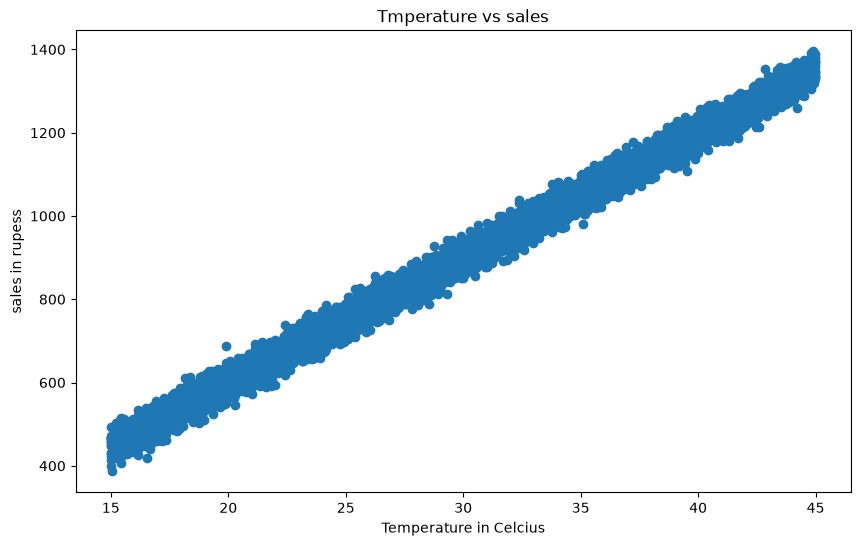

In [11]:
# eda
plt.figure(figsize=(10,6))
plt.scatter(df["Temperature_C"],df["IceCream_Sales"])
plt.xlabel("Temperature in Celcius")
plt.ylabel("sales in rupess")
plt.title("Tmperature vs sales")
plt.show()

In [12]:
# feature and target
X=df.drop(columns=["IceCream_Sales"])
y=df["IceCream_Sales"]
# train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
# print and test shape
print("trianing dataset shape:",X_train.shape)
print("test dataset shape:",X_test.shape)

trianing dataset shape: (7984, 1)
test dataset shape: (1996, 1)


In [14]:
# model training
model= LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[29.97]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature_C']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.234
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [15]:
# prediction
y_pred=model.predict(X_test)
df_predict=pd.DataFrame({"actual":y_test,"prediction":y_pred})
df_predict.head(10)

,actual,prediction
1256,1172.998845,1181.120156
8255,545.878857,592.101968
1662,1062.873181,1058.641167
7759,1042.490855,1042.442859
1444,495.767249,466.955083
1059,1106.610267,1090.910982
35,1204.757399,1188.703707
7174,824.931234,837.706840
1666,1284.483239,1272.203332
4055,625.665337,659.771506


In [16]:
# coefficient and intercept 
model_intercept=round(model.intercept_,2)
model_coef=round(model.coef_[0],2)
print("model_intercept:",model_intercept)
print("model_coef:",model_coef)

model_intercept: 1.23
model_coef: 29.97


In [17]:
# model evaluation
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
rmse=metrics.root_mean_squared_error(y_test,y_pred)
r2_score=metrics.r2_score(y_test,y_pred)

print("mean absoulute error:",mae)
print("mean squared error:",mse)
print("root mean squared error:",rmse)
print("R-squared scoore:",r2_score)

mean absoulute error: 15.656578427747068
mean squared error: 384.4210003721629
root mean squared error: 19.60665704224366
R-squared scoore: 0.9941246391745079


# problem :
- house price prediction based on feature like area , no. of bedroom , no. of bathroom,proximity , amenities etc
- dataset : housing.csv
- model:LinearRegression

In [18]:
# import
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

In [19]:
# load data 
data = pd.read_csv("Housing.csv")
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [20]:
# data back-up
df=data.copy()

### meta data

In [21]:
print("no. of rows:",df.shape[0])
print("no. of columns:",df.shape[1])
all_columns=df.columns.to_list()
num_columns=df.select_dtypes(include="number").columns.to_list()
cat_columns=df.select_dtypes(include="object").columns.to_list()

print("all columns: \n",all_columns)
print("\n numberic columns: \n",num_columns)
print("\n categorical columns: \n", cat_columns)
print("\ndata type: \n :", df.dtypes)
print("\ninfo: \n")
df.info()

no. of rows: 545
no. of columns: 13
all columns: 
 ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

 numberic columns: 
 ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

 categorical columns: 
 ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

data type: 
 : price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

info: 

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  --

## data pre-processing

In [22]:
# duplicate
print("total duplicate count:", df.duplicated().sum())
df[df.duplicated()]

total duplicate count: 0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


In [23]:
# null count
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# eda

In [24]:
# descriptive statistic 
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [25]:
df.describe(include="all")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [26]:
# feature and target
X=df.drop(columns=["price"])
y=df["price"]
# numeric and categorical features
num_features=X.select_dtypes(include="number").columns.to_list()
cat_features =X.select_dtypes(include="object").columns.to_list()
print("numeric feature: \n", num_features)
print("categorical feature:\n",cat_features)

numeric feature: 
 ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
categorical feature:
 ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [27]:
#  categorical dataframe and encodig
X_cat=X.select_dtypes(include="object")
X_cat.head()

# categorical encoding
X_cat=pd.get_dummies(X_cat,dtype="int64", drop_first=True)
X_cat.head()

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1,0,0,0,1,1,0,0
1,1,0,0,0,1,0,0,0
2,1,0,1,0,0,1,1,0
3,1,0,1,0,1,1,0,0
4,1,1,1,0,1,0,0,0


In [28]:
# numeric dataframe and scaling
X_num=X.select_dtypes(include="number")
X_num.head()                      

# train test split
X_num_train,X_num_test,y_train,y_test=train_test_split(X_num,y,test_size=0.2,random_state=42)

# intiliaza scaler
scaler=StandardScaler()


X_num_train=scaler.fit_transform(X_num_train)
X_num_test=scaler.transform(X_num_test)
X_num_train=pd.DataFrame(X_num_train,columns=num_features).reset_index(drop=True)
X_num_test=pd.DataFrame(X_num_test,columns=num_features).reset_index(drop=True)
X_num_train.head()

,area,bedrooms,bathrooms,stories,parking
0,0.384168,0.055271,1.539173,2.587644,0.367957
1,0.929181,0.055271,1.539173,-0.912499,2.709987
2,-0.607755,-1.283514,-0.557950,-0.912499,1.538972
3,-1.155492,0.055271,-0.557950,0.254215,-0.803059
4,-0.637730,0.055271,-0.557950,0.254215,-0.803059


In [29]:
# split on categorical datafrme
X_cat_train,X_cat_test=train_test_split(X_cat,test_size=0.2,random_state=42)
X_cat_train=X_cat_train.reset_index(drop=True)
X_cat_test=X_cat_test.reset_index(drop=True)

In [30]:
# merge data 
X_train=pd.concat([X_num_train,X_cat_train],axis=1)
X_test=pd.concat([X_num_test,X_cat_test],axis=1)

In [31]:
# model building and training
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 519552.42, 57349.56, 521879.03,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.969e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [32]:
# prediction
y_pred=model.predict(X_test)
df_predict=pd.DataFrame({"Actual":y_test,"prediction":y_pred})
df_predict.head(10)

,Actual,prediction
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


In [33]:
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
rmse=metrics.root_mean_squared_error(y_test,y_pred)
r2_score=metrics.r2_score(y_test,y_pred)

print("mean absoulute error:",mae)
print("mean squared error:",mse)
print("root mean squared error:",rmse)
print("R-squared scoore:",r2_score)

mean absoulute error: 970043.4039201641
mean squared error: 1754318687330.668
root mean squared error: 1324506.9600914402
R-squared scoore: 0.6529242642153176
